# Requirements

In [ ]:
#!pip install ibge

## Imports

In [13]:
from ibge.localidades import *
import pandas as pd
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Dados da Biblioteca IBGE

### Dados Gerais (Municipio, Estado, Regiao)

In [20]:
dados_regiao = Regioes()
dados_estados = Estados()
dados_municipios = Municipios()
if isinstance(dados_municipios.json_ibge, (list, dict)):
    dt = dados_municipios.json_ibge  # Já é uma estrutura Python válida
    print(dt)
else:
    dt = json.loads(dados_municipios.json_ibge)  # Caso seja uma string JSON
    print(dt)
dt[0]

[{'id': 1100015, 'nome': "Alta Floresta D'Oeste", 'microrregiao': {'id': 11006, 'nome': 'Cacoal', 'mesorregiao': {'id': 1102, 'nome': 'Leste Rondoniense', 'UF': {'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}, 'regiao-imediata': {'id': 110005, 'nome': 'Cacoal', 'regiao-intermediaria': {'id': 1102, 'nome': 'Ji-Paraná', 'UF': {'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}}, {'id': 1100023, 'nome': 'Ariquemes', 'microrregiao': {'id': 11003, 'nome': 'Ariquemes', 'mesorregiao': {'id': 1102, 'nome': 'Leste Rondoniense', 'UF': {'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}, 'regiao-imediata': {'id': 110002, 'nome': 'Ariquemes', 'regiao-intermediaria': {'id': 1101, 'nome': 'Porto Velho', 'UF': {'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}}, {'id': 1100031, 'nome': 'Cabixi', 'microrregi

{'id': 1100015,
 'nome': "Alta Floresta D'Oeste",
 'microrregiao': {'id': 11006,
  'nome': 'Cacoal',
  'mesorregiao': {'id': 1102,
   'nome': 'Leste Rondoniense',
   'UF': {'id': 11,
    'sigla': 'RO',
    'nome': 'Rondônia',
    'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}},
 'regiao-imediata': {'id': 110005,
  'nome': 'Cacoal',
  'regiao-intermediaria': {'id': 1102,
   'nome': 'Ji-Paraná',
   'UF': {'id': 11,
    'sigla': 'RO',
    'nome': 'Rondônia',
    'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}}}}

## Extração dos dados dos Estados

In [19]:
# Busco as informações dos estados
dados_estados = Estados()
if isinstance(dados_estados.json_ibge, (list, dict)):
    dt_est = dados_estados.json_ibge  # Já é uma estrutura Python válida
    print(dt_est)
else:
    dt_est = json.loads(dados_estados.json_ibge)  # Caso seja uma string JSON
    print(dt_est)
dt_est[17]

# Extraindo corretamente as informações de estado e região
dados_est = []
for dado in dt_est:
    linha = {
        "id": dado["id"],
        "sigla": dado["sigla"],
        "nome": dado["nome"],
        "regiao": dado["regiao"]["nome"]  # Acessa o nome da região corretamente
    }
    dados_est.append(linha)

# Criar DataFrame com as informações de estados e regiões
df_estados = pd.DataFrame(dados_est)  
print(df_estados.head())

[{'id': 11, 'sigla': 'RO', 'nome': 'Rondônia', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 12, 'sigla': 'AC', 'nome': 'Acre', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 13, 'sigla': 'AM', 'nome': 'Amazonas', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 14, 'sigla': 'RR', 'nome': 'Roraima', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 15, 'sigla': 'PA', 'nome': 'Pará', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 16, 'sigla': 'AP', 'nome': 'Amapá', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 17, 'sigla': 'TO', 'nome': 'Tocantins', 'regiao': {'id': 1, 'sigla': 'N', 'nome': 'Norte'}}, {'id': 21, 'sigla': 'MA', 'nome': 'Maranhão', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 22, 'sigla': 'PI', 'nome': 'Piauí', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 23, 'sigla': 'CE', 'nome': 'Ceará', 'regiao': {'id': 2, 'sigla': 'NE', 'nome': 'Nordeste'}}, {'id': 24, 'si

### Dados dos municipios

In [21]:
dados_municipios = Municipios()
dados_mun = []
for dado in dt:
    linha = {
        "id": dado["id"],
        "nome": dado["nome"],
        "microrregiao_nome": dado["microrregiao"]["nome"],
        "mesorregiao_nome": dado["microrregiao"]["mesorregiao"]["nome"],
        "uf_sigla": dado["microrregiao"]["mesorregiao"]["UF"]["sigla"],
        "regiao_nome": dado["microrregiao"]["mesorregiao"]["UF"]["regiao"]["nome"],
    }
    dados_mun.append(linha)

df_cidades = pd.DataFrame(dados_mun)    
df_cidades

,id,nome,microrregiao_nome,mesorregiao_nome,uf_sigla,regiao_nome
0,1100015,Alta Floresta D'Oeste,Cacoal,Leste Rondoniense,RO,Norte
1,1100023,Ariquemes,Ariquemes,Leste Rondoniense,RO,Norte
2,1100031,Cabixi,Colorado do Oeste,Leste Rondoniense,RO,Norte
3,1100049,Cacoal,Cacoal,Leste Rondoniense,RO,Norte
4,1100056,Cerejeiras,Colorado do Oeste,Leste Rondoniense,RO,Norte
...,...,...,...,...,...,...
5565,5222005,Vianópolis,Pires do Rio,Sul Goiano,GO,Centro-Oeste
5566,5222054,Vicentinópolis,Meia Ponte,Sul Goiano,GO,Centro-Oeste
5567,5222203,Vila Boa,Entorno de Brasília,Leste Goiano,GO,Centro-Oeste
5568,5222302,Vila Propício,Entorno de Brasília,Leste Goiano,GO,Centro-Oeste


## Fazendo o join entre as notificações do WSUS e a biblioteca IBGE

### Busca dos dados já processados do WSUS

In [5]:
print("-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------")
arquivos = []
path_csv = os.path.join('.', 'data', 'HANS')

# Garantir que o diretório existe
if not os.path.exists(path_csv):
    print(f"Diretório não encontrado: {path_csv}")
    os.makedirs(path_csv)  # Criar o diretório se não existir

# Verificar arquivos no diretório
for f in os.listdir(path_csv):
    if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
        try:
            # Extrair data do nome do arquivo
            data_str = f.split('_')[-3:]  # Pega os últimos 3 elementos (dd, mm, yyyy)
            data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
            arquivos.append((data, f))
        except Exception as e:
            print(f"Arquivo com formato inválido: {f} - {e}")

# Executar script externo se nenhum arquivo for encontrado
if not arquivos:
    print("Nenhum arquivo encontrado. Executando script para gerar arquivo...")
    path_gerar_wsus = os.path.join('.', 'gerar_wsus_csv.py')
    resultado = os.system('python ' + path_gerar_wsus)
    
    if resultado == 0:
        print("Script executado com sucesso. Verificando novo arquivo...")
        # Recarregar lista de arquivos após execução do script
        for f in os.listdir(path_csv):
            if f.startswith('HANSENIASE_PROCESS_') and f.endswith('.csv'):
                try:
                    data_str = f.split('_')[-3:]
                    data = datetime.strptime('_'.join(data_str).replace('.csv', ''), '%d_%m_%Y')
                    arquivos.append((data, f))
                except Exception as e:
                    print(f"Erro ao processar novo arquivo: {f} - {e}")
    else:
        print("Erro na execução do script. Arquivo não gerado.")

# Exibir lista final de arquivos encontrados
print("Arquivos encontrados:", arquivos)

if arquivos:
    # Ordenar arquivos pela data mais recente
    arquivos.sort(reverse=True, key=lambda x: x[0])
    
    # Pegar arquivo mais recente
    ultimo_arquivo = os.path.join(path_csv, arquivos[0][1])
    
    print(f"Carregando arquivo mais recente: {ultimo_arquivo}")
    
    # Carregar dados
    df_dados = pd.read_csv(ultimo_arquivo, encoding='utf-8', low_memory=False)
    
    print("\nPrimeiras linhas do DataFrame:")
    print(f"\nTotal de registros: {len(df_dados):,}")
    print(f"Data de referência: {arquivos[0][0].strftime('%d/%m/%Y')}")
else:
    print("Nenhum arquivo válido encontrado na pasta")

-----------------------------------BUSCA DOS DADOS JÁ PROCESSADOS---------------------------
Arquivos encontrados: [(datetime.datetime(2025, 3, 6, 0, 0), 'HANSENIASE_PROCESS_06_03_2025.csv')]
Carregando arquivo mais recente: .\data\HANS\HANSENIASE_PROCESS_06_03_2025.csv

Primeiras linhas do DataFrame:

Total de registros: 984,035
Data de referência: 06/03/2025


### Associação por Estado (Separados por Região)

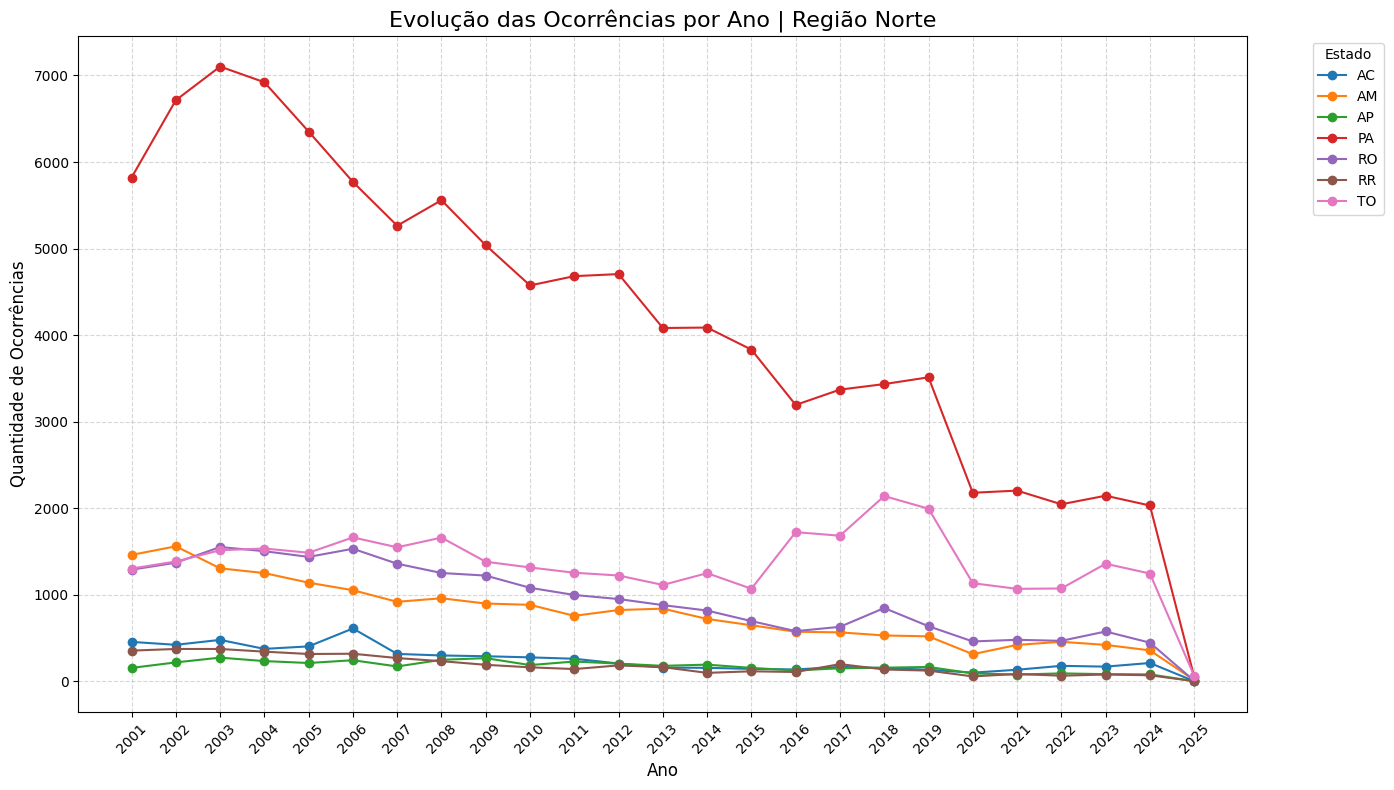

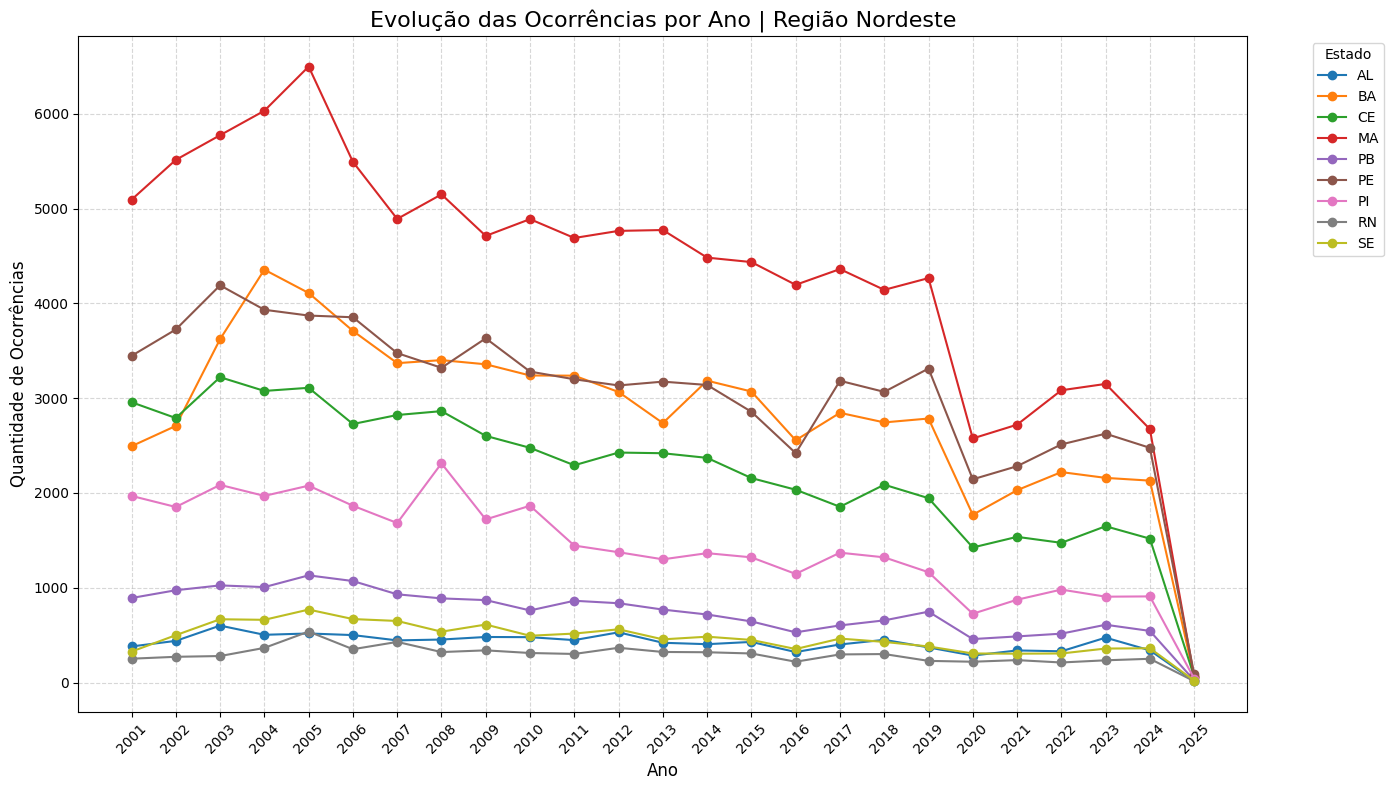

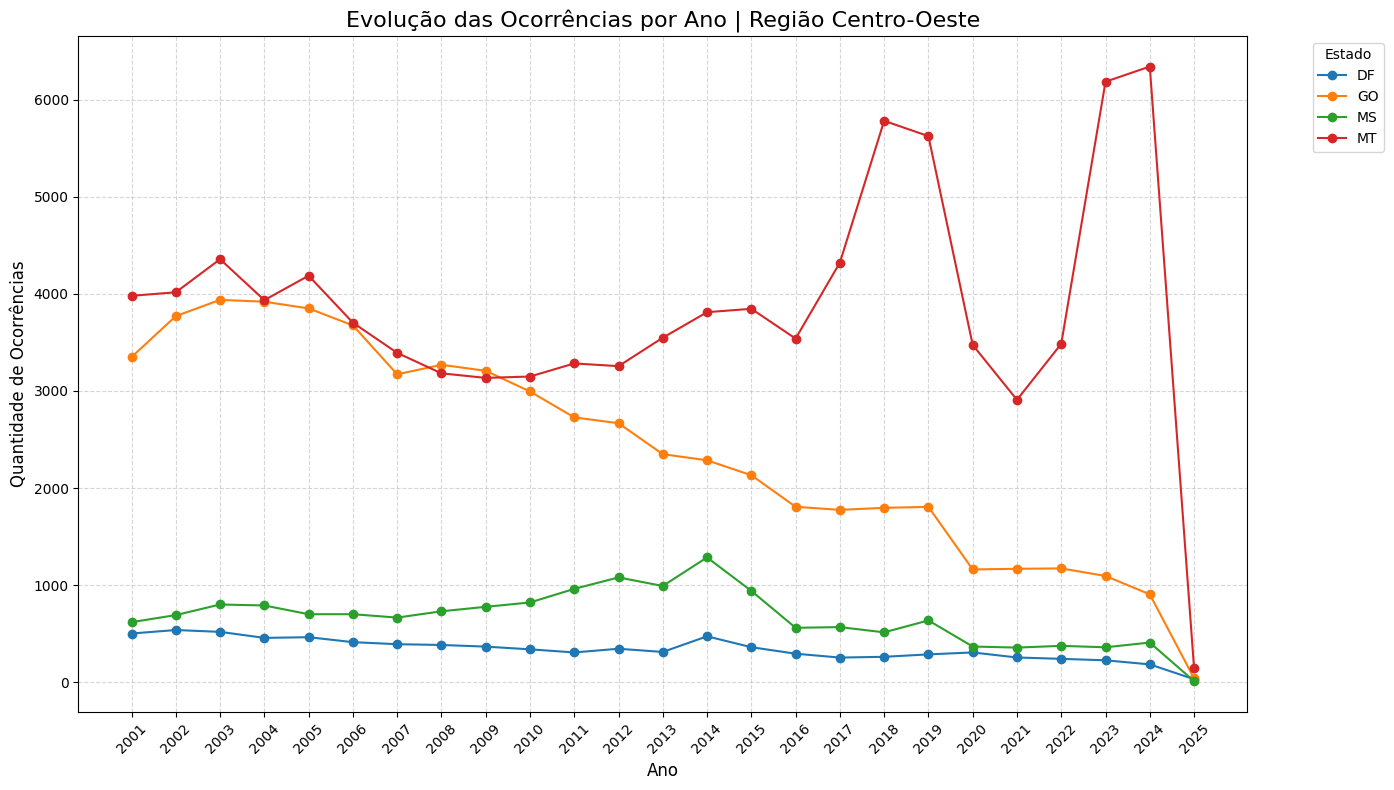

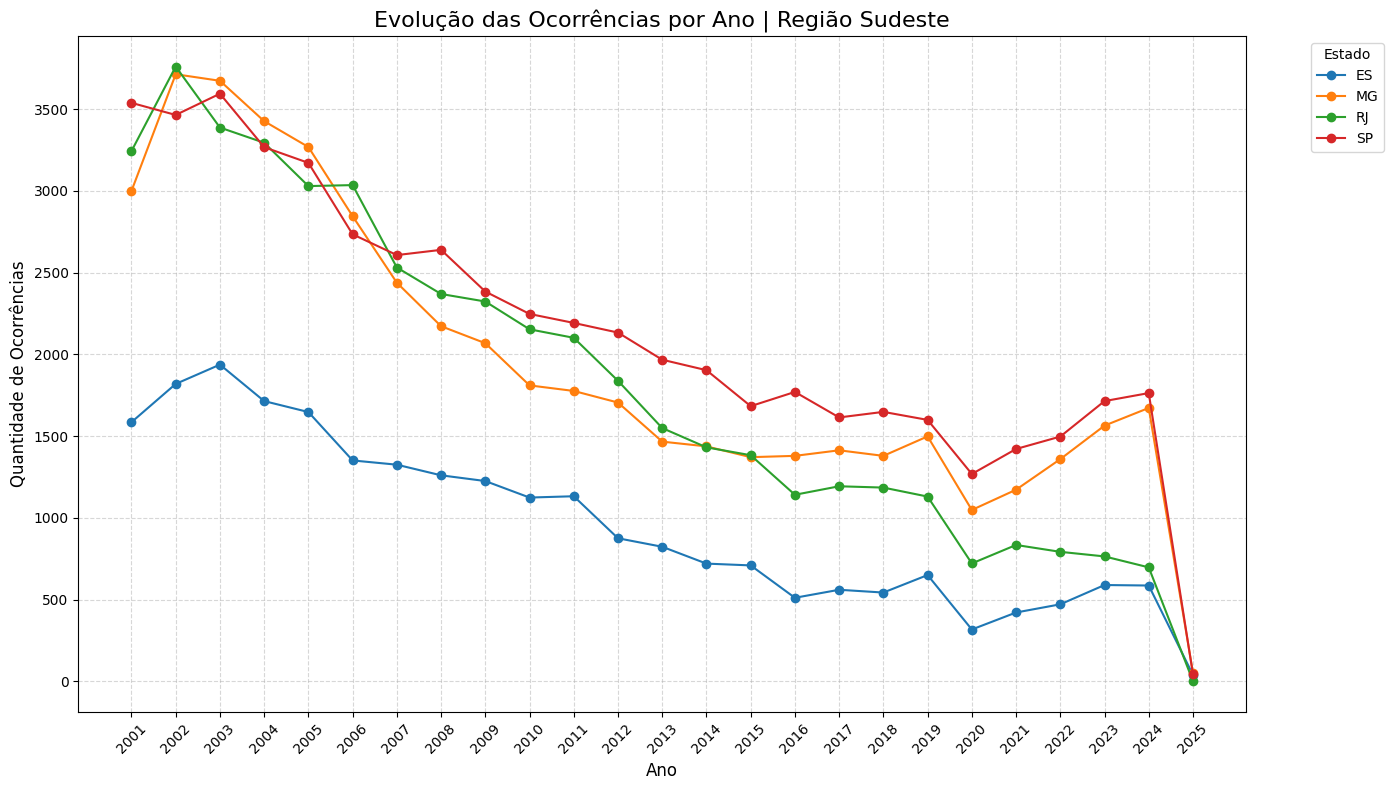

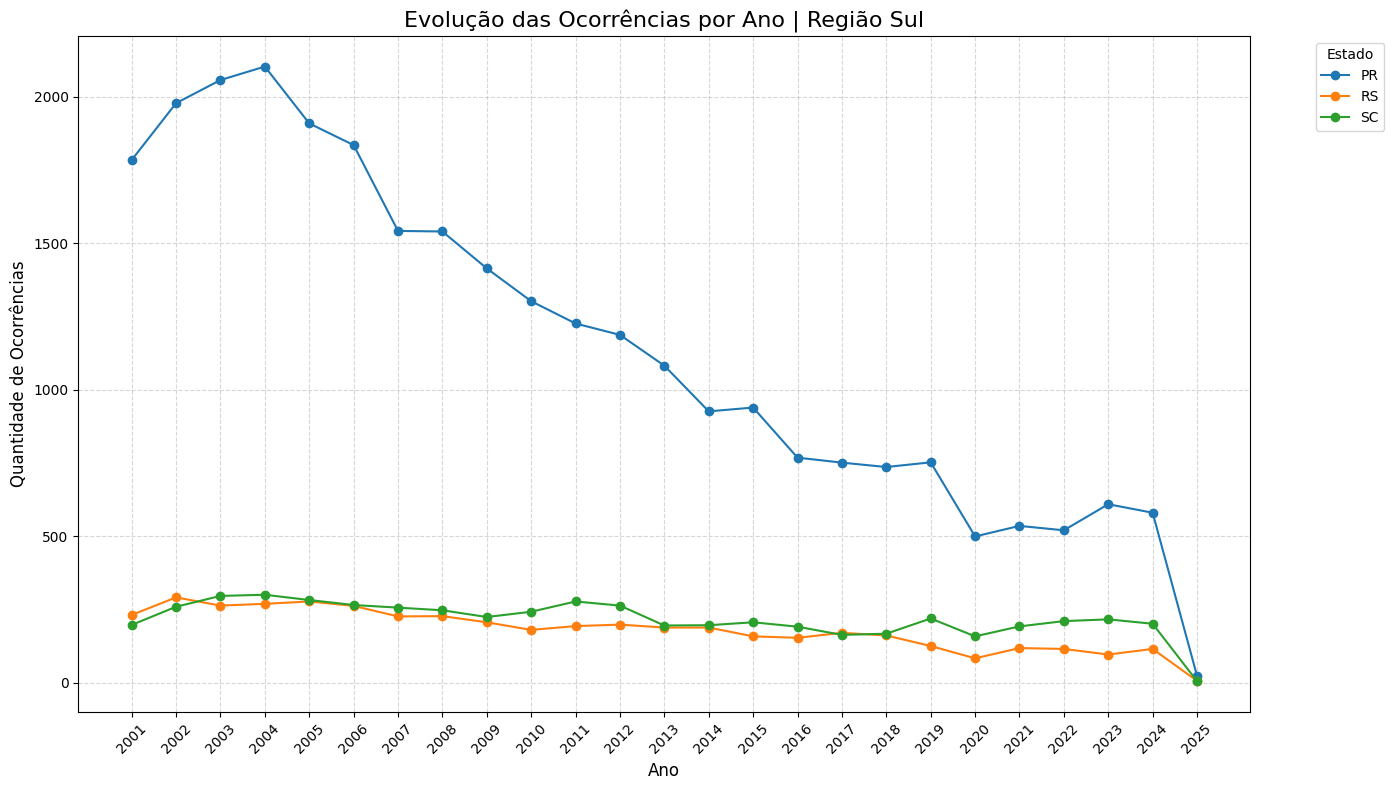

In [8]:
# Criar DataFrame de estados
df_estados = pd.DataFrame(dados_est)

# Adicionar ao DataFrame original uma coluna para os nomes dos estados e regiões
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano, estado e região
dados_agrupados = df_dados_estado.groupby(['NU_ANO', 'sigla', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados['regiao'].unique()

# Criar gráficos de linha para cada região
for regiao in regioes:
    fig, ax = plt.subplots(figsize=(14, 8))

    dados_regiao = dados_agrupados[dados_agrupados['regiao'] == regiao]

    for estado in dados_regiao['sigla'].unique():
        dados_estado = dados_regiao[dados_regiao['sigla'] == estado]
        ax.plot(
            dados_estado['NU_ANO'],
            dados_estado['quantidade'],
            marker='o',
            label=estado
        )

    # Configurar títulos e rótulos
    ax.set_title(f'Evolução das Ocorrências por Ano | Região {regiao}', fontsize=16)
    ax.set_xlabel('Ano', fontsize=12)
    ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

    # Melhorar a visualização
    plt.xticks(dados_agrupados['NU_ANO'].unique(), rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title="Estado", bbox_to_anchor=(1.05, 1), loc='upper left')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()

    # Exibir o gráfico para a região atual
    plt.show()


### Por Região

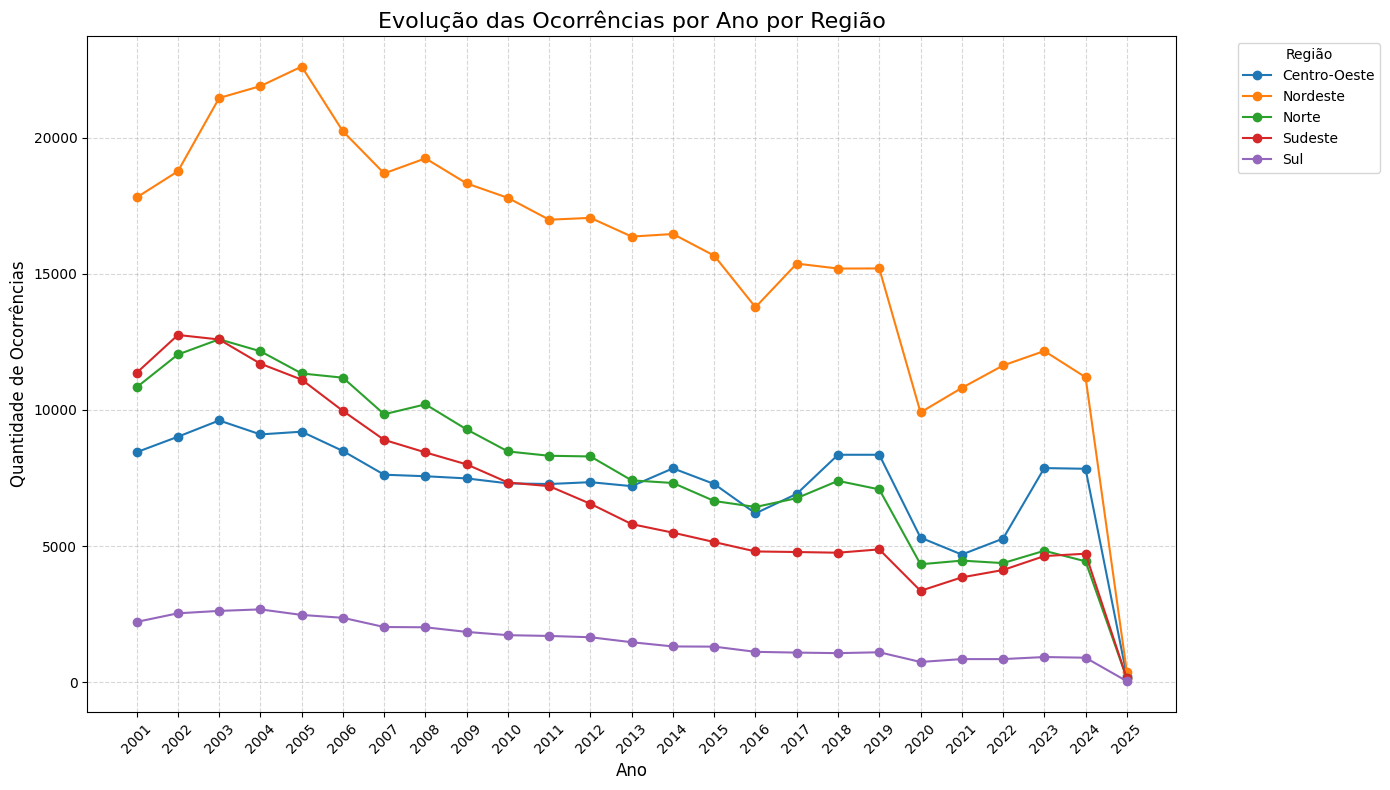

In [9]:

# Criar DataFrame de estados com regiões
df_estados = pd.DataFrame(dados_est)

# Adicionar a coluna de região ao DataFrame de dados com base no estado
df_dados_estado = df_dados.merge(df_estados[['id', 'sigla', 'regiao']], left_on='SG_UF_NOT', right_on='id', how='left')

# Agrupar por ano e região (agora sem separar por estado)
dados_agrupados_regiao = df_dados_estado.groupby(['NU_ANO', 'regiao']).size().reset_index(name='quantidade')

# Obter lista única de regiões
regioes = dados_agrupados_regiao['regiao'].unique()

# Criar um gráfico de linha para todos os dados por região
fig, ax = plt.subplots(figsize=(14, 8))

# Plotar as ocorrências totais para cada região ao longo dos anos
for regiao in regioes:
    dados_regiao = dados_agrupados_regiao[dados_agrupados_regiao['regiao'] == regiao]
    ax.plot(
        dados_regiao['NU_ANO'],
        dados_regiao['quantidade'],
        marker='o',
        label=regiao
    )

# Configurar o título e rótulos dos eixos
ax.set_title('Evolução das Ocorrências por Ano por Região', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Quantidade de Ocorrências', fontsize=12)

# Melhorar a visualização
plt.xticks(dados_agrupados_regiao['NU_ANO'].unique(), rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Exibir legenda com as regiões
ax.legend(title="Região", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()


### Associação com os dados populacionais vindos do SIDRA 

Em caso de dúvida o passo a passo está no arquivo `gerar_populacao_ibge.ipynb` de como foi obtido o arquivo que será carregado.

In [10]:
# Carregar os dados
path_dados_ibge = os.path.join('.', 'data', 'IBGE','populacao_municipios.csv')
dados_ibge = pd.read_csv(path_dados_ibge)

#### Informações do dataframe

In [11]:
dados_ibge.info()
dados_ibge.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150950 entries, 0 to 150949
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   ano             150950 non-null  int64 
 1   id_municipio    150950 non-null  int64 
 2   nome_municipio  150950 non-null  object
 3   sigla_uf        150950 non-null  object
 4   pessoas         150950 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 5.8+ MB


,ano,id_municipio,nome_municipio,sigla_uf,pessoas
0,1970,1100106,Guajará-Mirim,RO,27016
1,1970,1100205,Porto Velho,RO,84048
2,1970,1200104,Brasiléia,AC,12311
3,1970,1200203,Cruzeiro do Sul,AC,43584
4,1970,1200302,Feijó,AC,15768


### Agrupar por ano e somar o número de pessoas

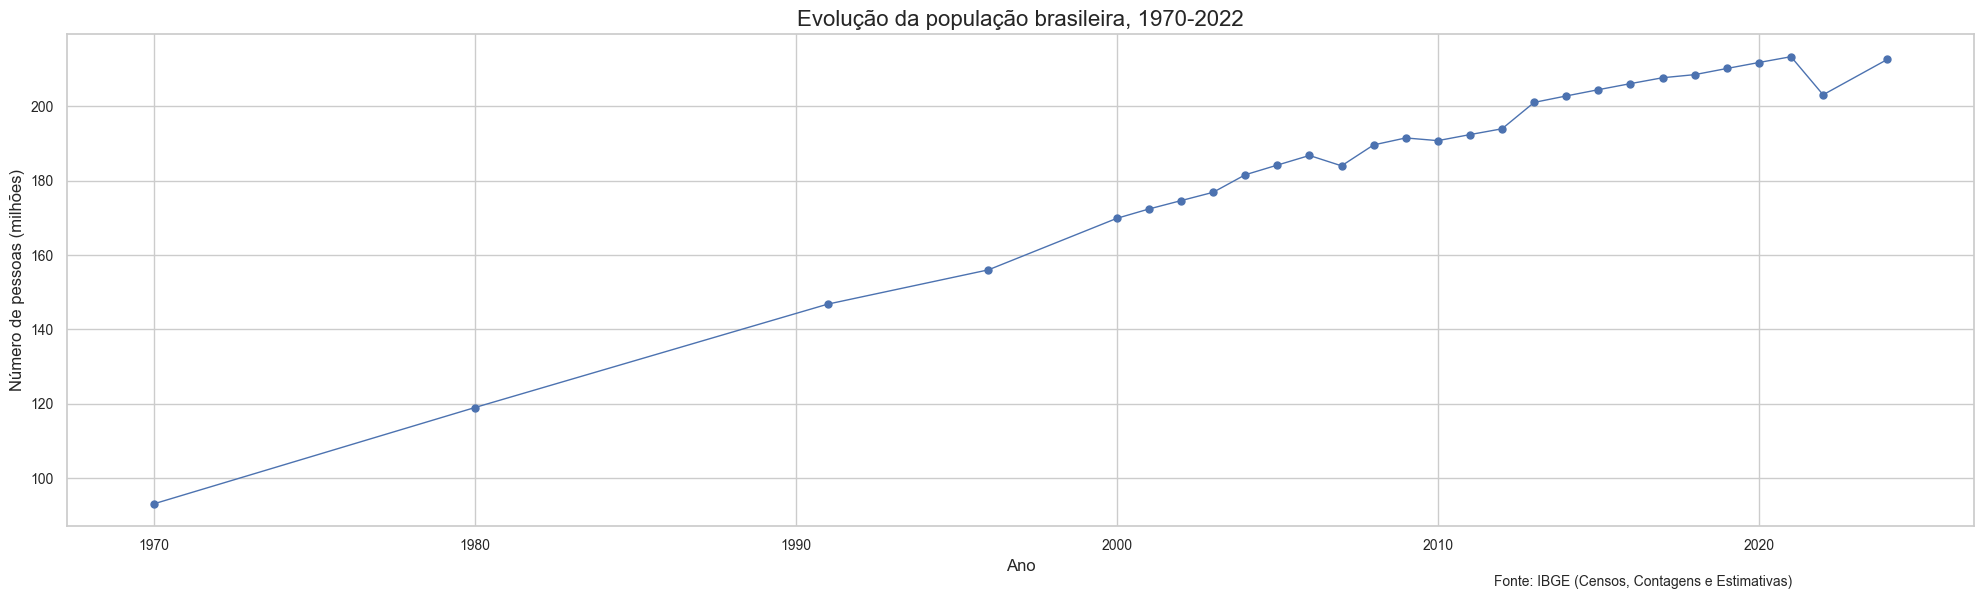

In [15]:
dados_agrupados = (
    dados_ibge.groupby("ano", as_index=False)
    .agg(n_pessoas=("pessoas", "sum"))
)

# Configurar o estilo do gráfico
sns.set_theme(style="whitegrid")

# Criar o gráfico
plt.figure(figsize=(20, 6))
plt.plot(dados_agrupados["ano"], dados_agrupados["n_pessoas"] / 1_000_000, 
         linewidth=1, marker="o", markersize=5)

# Personalizar o gráfico
plt.title("Evolução da população brasileira, 1970-2022", fontsize=16)
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de pessoas (milhões)", fontsize=12)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))  # Formatar os números no eixo Y
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.figtext(0.9, 0.01, "Fonte: IBGE (Censos, Contagens e Estimativas)", fontsize=10, ha="right")

# Exibir o gráfico
plt.tight_layout()
plt.show()
